In [1]:
from exoatlas import * 

In [18]:
!ls -lrth

total 14832
-rw-r--r--@ 1 zabe0091  staff   7.2M Oct 12 13:49 all-any-uncertainties=True-numpyro.nc
-rw-r--r--@ 1 zabe0091  staff   3.0K Oct 12 13:52 test-atmosphere-probability.ipynb


In [14]:
s = SolarSystem()
import arviz as az
posterior = az.from_netcdf('all-any-uncertainties=True-numpyro.nc') 
from exoatlas.populations.calculations.shoreline import * 
shoreline = Shoreline(posterior)

In [15]:
s.probability_of_atmosphere(shoreline=shoreline)

<Quantity [0.09943326, 0.99972715, 0.99995215, 0.9754446 , 1.        ,
           1.        , 1.        , 1.        ]>

In [16]:
s.probability_of_atmosphere_uncertainty(shoreline=shoreline)

<Quantity [1.25630417e-01, 4.16242678e-04, 1.19971255e-04, 1.63562818e-02,
           8.31701374e-12, 9.18911058e-11, 9.56494606e-10, 1.64145253e-10]>

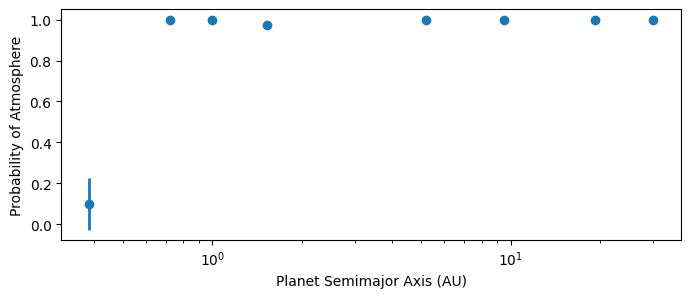

In [24]:
from exoatlas import *
from exoatlas.populations.calculations.shoreline import * 

def test_probability_of_atmosphere():
    # need to change for other people to be able to run tests
    posterior_filename = '/Users/zabe0091/Dropbox/zach/code/exoatlas/sandbox/shoreline/all-any-uncertainties=True-numpyro.nc'
    # need to add automatic download for posteriors!
    s = SolarSystem()
    import arviz as az
    posterior = az.from_netcdf(posterior_filename) 
    shoreline = Shoreline(posterior)

    p = s.probability_of_atmosphere(shoreline=shoreline)
    p_uncertainty = s.probability_of_atmosphere_uncertainty(shoreline=shoreline)

    plt.figure(figsize=(8,3))
    plt.errorbar(s.semimajoraxis(), p, p_uncertainty, linewidth=0, elinewidth=2, marker='o')
    plt.xscale('log')
    plt.xlabel('Planet Semimajor Axis (AU)')
    plt.ylabel('Probability of Atmosphere')
test_probability_of_atmosphere()
